# Fase 18: Análisis de errores, explicabilidad e incertidumbre

## 18.1 Análisis de errores

- Residuos en el tiempo: ¿eran predecibles? ¿se concentran en regímenes de alta volatilidad (2024)?
- Errores por año y por nivel de precios.
- Peores predicciones: sobre/subestimaciones extremas.

## 18.2 Explicabilidad

- **SHAP** (muestra de test): qué mueve el precio predicho. Para el modelo
  lineal final (Ridge) se usa `LinearExplainer` (los TreeExplainer solo
  aplican a modelos de árboles).
- PDP para las variables más importantes.

## 18.3 Incertidumbre

- **Intervalos por cuantiles de ensemble bootstrap**: se reentrena el modelo
  con submuestras de train y se calcula el percentil 5-95 de las predicciones.
- Cobertura empírica de los intervalos en test.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, path_from_root, set_seed
set_seed(42)
set_publication_style()

Carga de datos y predicciones en test.

Cargamos test, artefactos y calculamos predicción y residuos. Todo con el
modelo congelado (mismo preprocesador, mismo orden de features).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import get_config
from src.data.split import temporal_split, drop_warmup
from src.models.train_model import load_model_artifacts
from src.utils import set_publication_style, save_fig, save_json

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]

te = parts["test"]
X_te = pp.transform(te[sel_cols].to_numpy(dtype=np.float64))
y_te = te[f"target_{h}"].to_numpy(dtype=np.float64)
y_pred = model.predict(X_te)
resid = y_te - y_pred

out = te[["date"]].copy()
out["y_true"], out["y_pred"], out["resid"] = y_te, y_pred, resid
out["year"] = out["date"].dt.year
print(f"Modelo: {type(model).__name__} | test: {len(te)}")

Modelo: Ridge | test: 684


18.1 Análisis de errores.

- Serie temporal de residuos (¿hay patrones?).
- Error medio/desv. por año (¿degradación temporal?).
- Histograma de residuos y peores errores absolutos.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\error_analysis.png
MAE por año:
year
2023     38.28
2024     99.72
2025    193.36

Peores 5 errores:
      date  y_true  y_pred  resid
2025-05-05 3430.21 2992.36 437.85
2025-04-18 3424.30 3009.03 415.27
2025-04-15 3343.22 2947.72 395.50
2025-04-21 3382.54 3010.23 372.31
2025-05-06 3365.21 2995.79 369.42


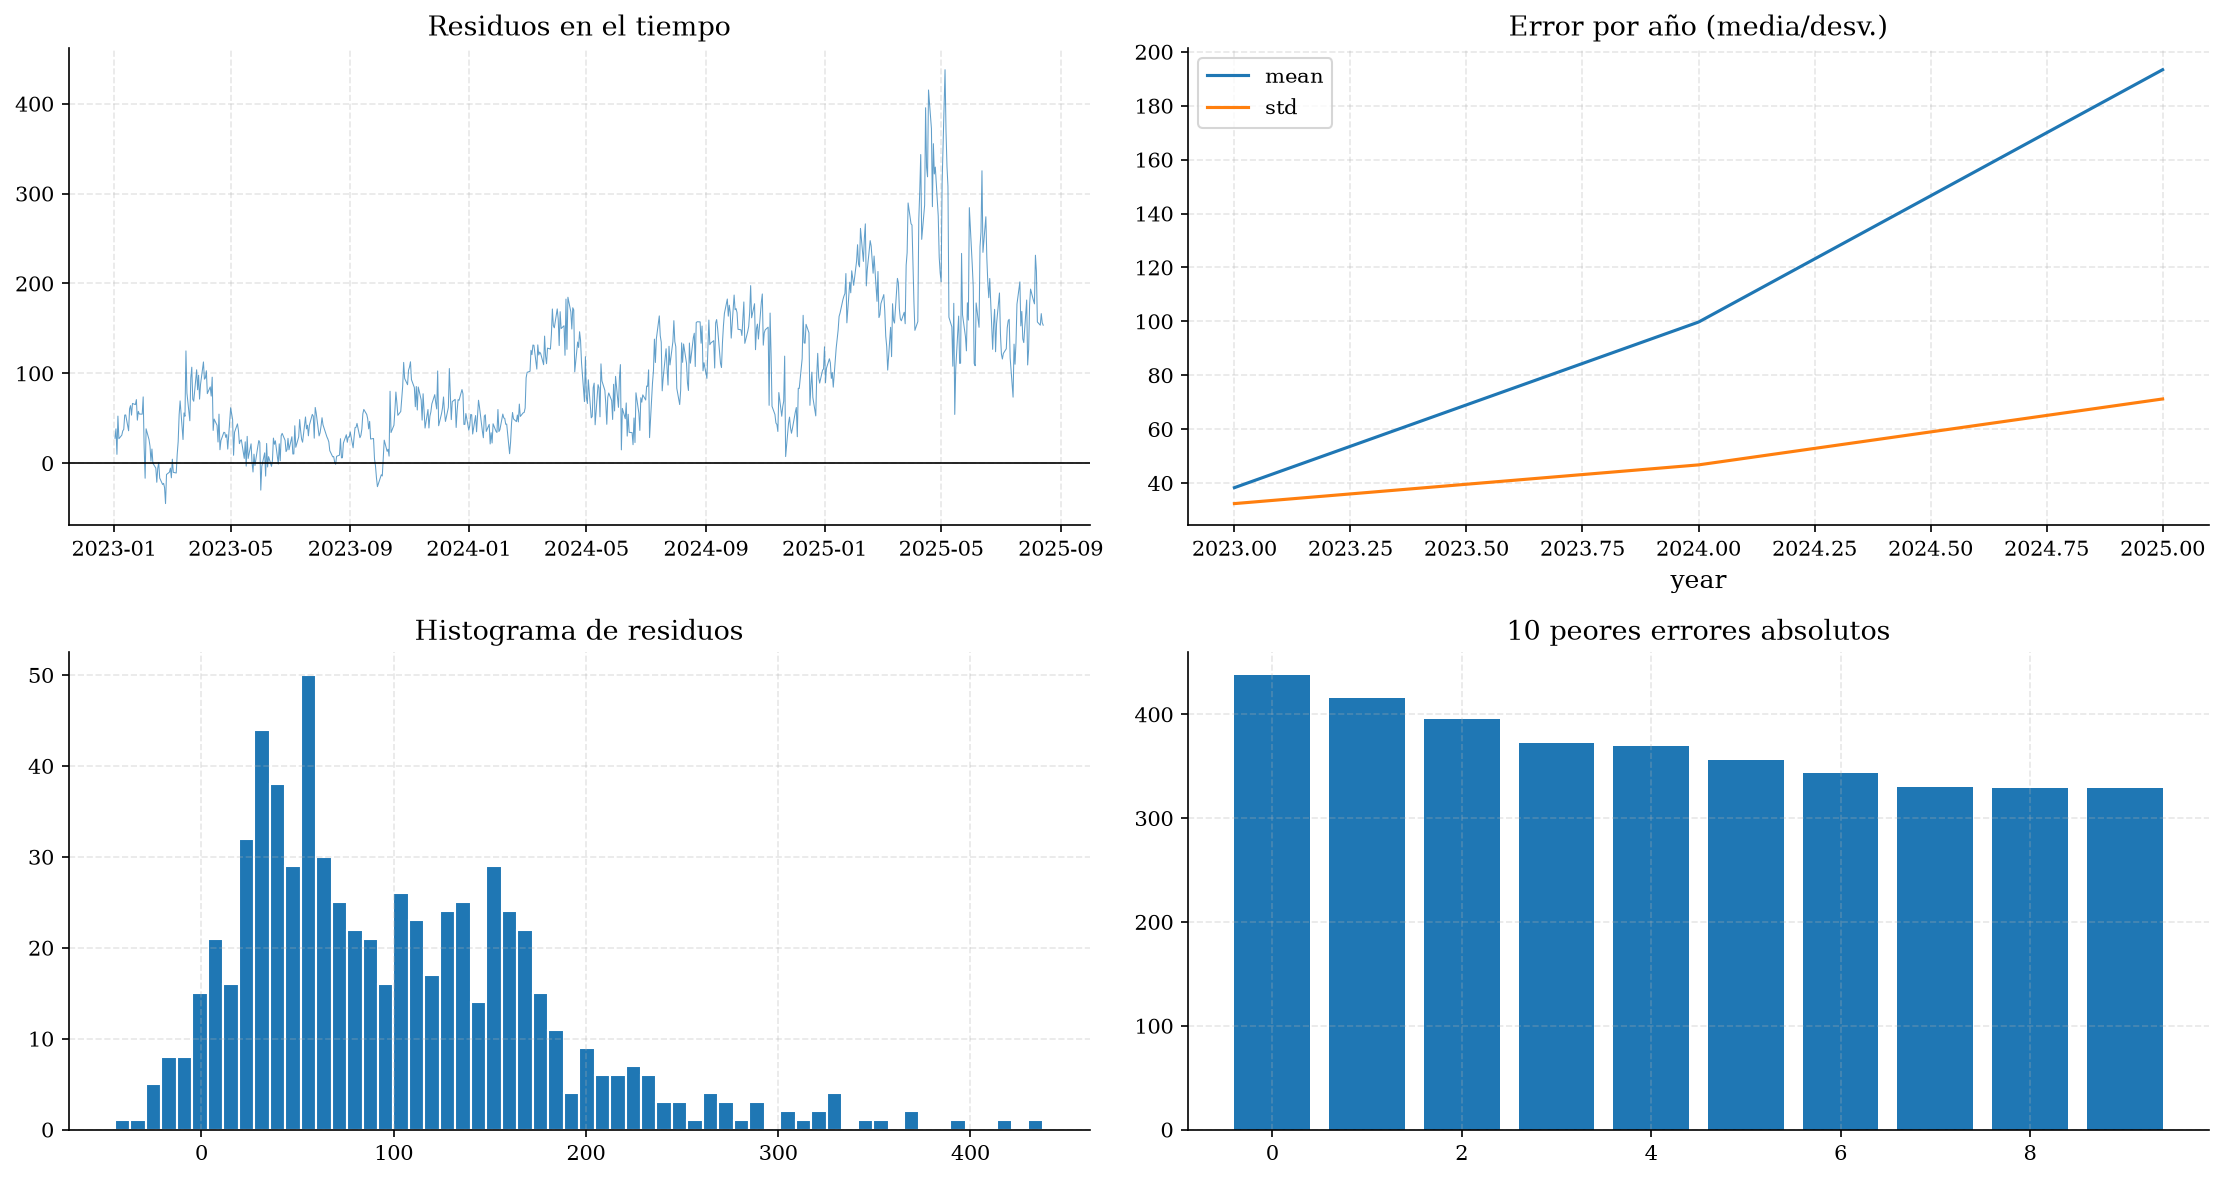

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes[0, 0].plot(out["date"], out["resid"], lw=0.5, alpha=0.7)
axes[0, 0].axhline(0, color="k", lw=0.8)
axes[0, 0].set_title("Residuos en el tiempo")

by_year = out.groupby("year")["resid"].agg(["mean", "std", "count"])
by_year.plot(y=["mean", "std"], ax=axes[0, 1], title="Error por año (media/desv.)")

axes[1, 0].hist(resid, bins=60, edgecolor="white")
axes[1, 0].set_title("Histograma de residuos")

worst = out.assign(ae=np.abs(resid)).sort_values("ae", ascending=False).head(10)
axes[1, 1].bar(range(len(worst)), worst["ae"])
axes[1, 1].set_title("10 peores errores absolutos")
fig.tight_layout()
save_fig(fig, "error_analysis.png")

print("MAE por año:")
print(by_year["mean"].abs().round(2).to_string())
print("\nPeores 5 errores:")
print(worst[["date", "y_true", "y_pred", "resid"]].head()
      .assign(y_true=lambda d: d["y_true"].round(2),
             y_pred=lambda d: d["y_pred"].round(2),
             resid=lambda d: d["resid"].round(2))
      .to_string(index=False))

18.2 Explicabilidad con SHAP (modelo lineal).

Para Ridge se usa `LinearExplainer` (exacto para modelos lineales). Se
calcula sobre una muestra de 300 puntos de test para no penalizar el
tiempo de cómputo. El summary plot muestra el impacto de cada feature.

C:\Users\sgml1\Desktop\gold-price-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sgml1\AppData\Local\Temp\ipykernel_13036\3798768625.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_te[sample_idx], feature_names=sel_cols,


[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\shap_summary.png

Top 15 importancias SHAP:
gold_spot_lag21            338.3750
gold_ret_roll21             26.6969
silver_spot                 14.0760
commodities_crb              3.3410
quarter                      3.0426
platinum_spot                2.7007
usdjpy_exchange              2.6423
policy_uncertainty           2.5908
commodities_bloomberg        2.4630
dayofyear                    2.3730
gold_rollstd_63              2.2897
us10y_yield                  2.2792
year                         2.2740
policy_uncertainty_lag1      2.2387
copper_futures               1.9202
[json] C:\Users\sgml1\Desktop\gold-price-prediction\reports\shap_importances.json


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/shap_importances.json')

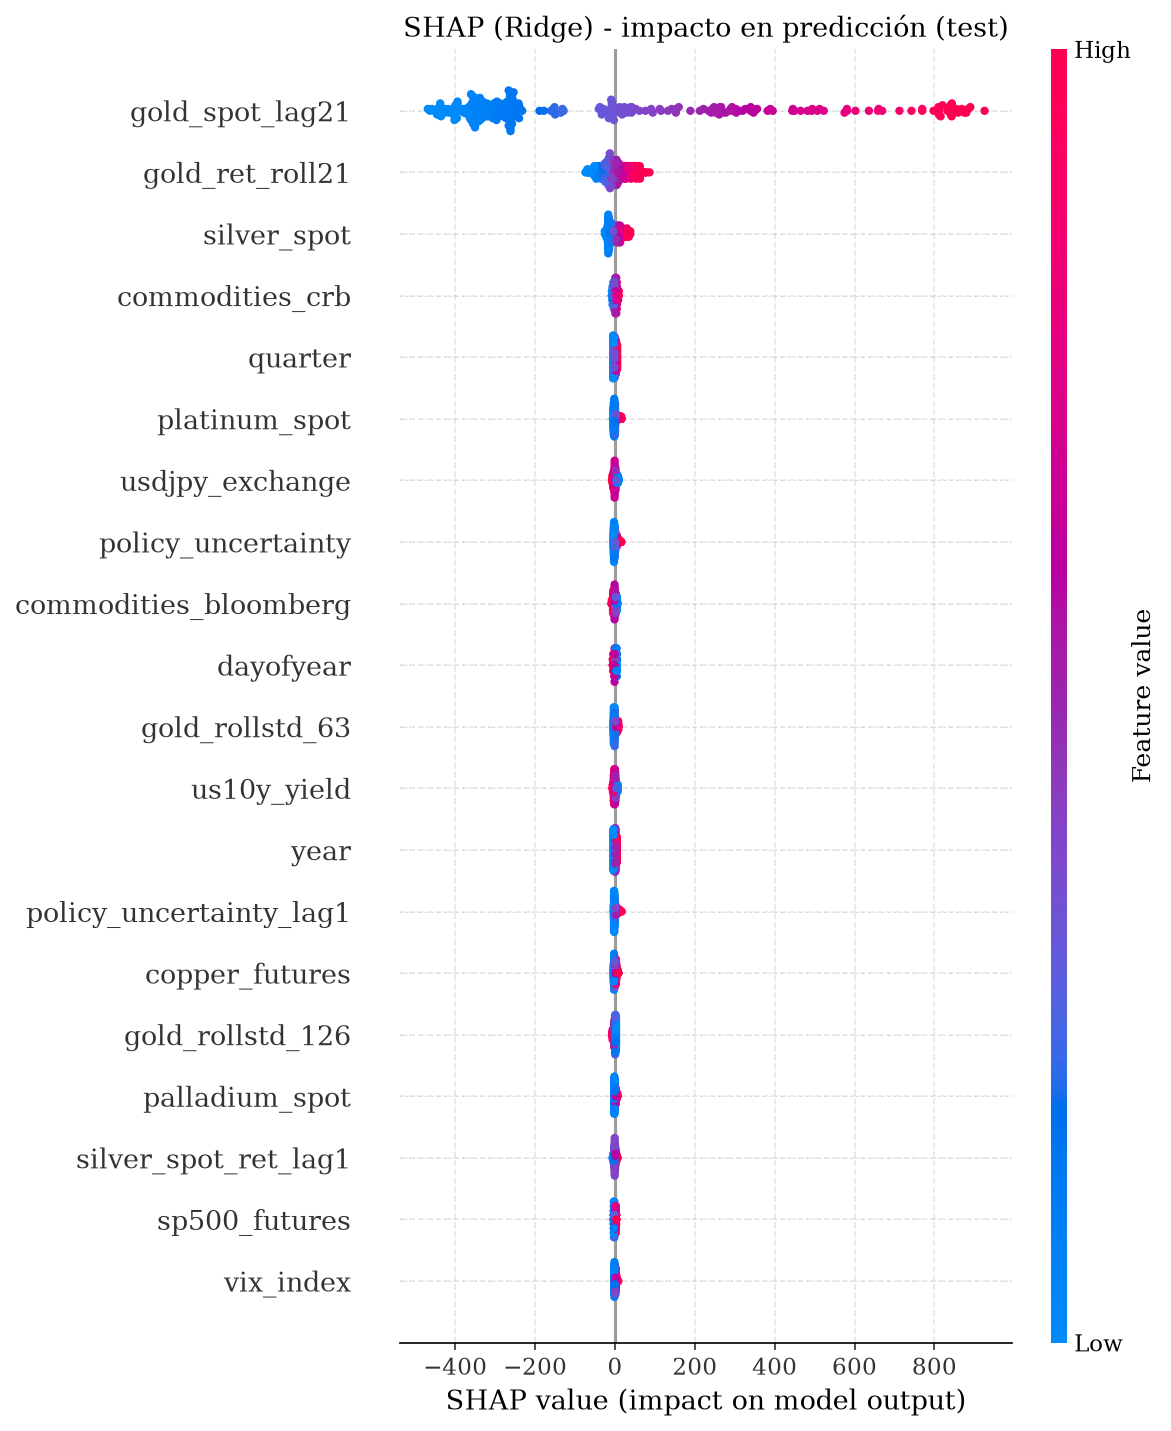

In [4]:
import shap

sample_idx = np.random.default_rng(42).choice(
    len(X_te), size=min(300, len(X_te)), replace=False)
explainer = shap.LinearExplainer(model, X_te[sample_idx])
shap_values = explainer.shap_values(X_te[sample_idx])

fig = plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_te[sample_idx], feature_names=sel_cols,
                  show=False, max_display=20)
plt.title("SHAP (Ridge) - impacto en predicción (test)")
save_fig(fig, "shap_summary.png")

imp = pd.Series(np.abs(shap_values).mean(axis=0), index=sel_cols) \
    .sort_values(ascending=False)
print("\nTop 15 importancias SHAP:")
print(imp.head(15).round(4).to_string())
save_json(imp.head(30).round(5).to_dict(), "shap_importances.json")

18.2 PDP para las 3 variables más importantes.

Partial Dependence Plot: cómo cambia la predicción al variar una feature
(manteniendo el resto en su valor medio). Se usa la muestra de test.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\pdp_top3.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/pdp_top3.png')

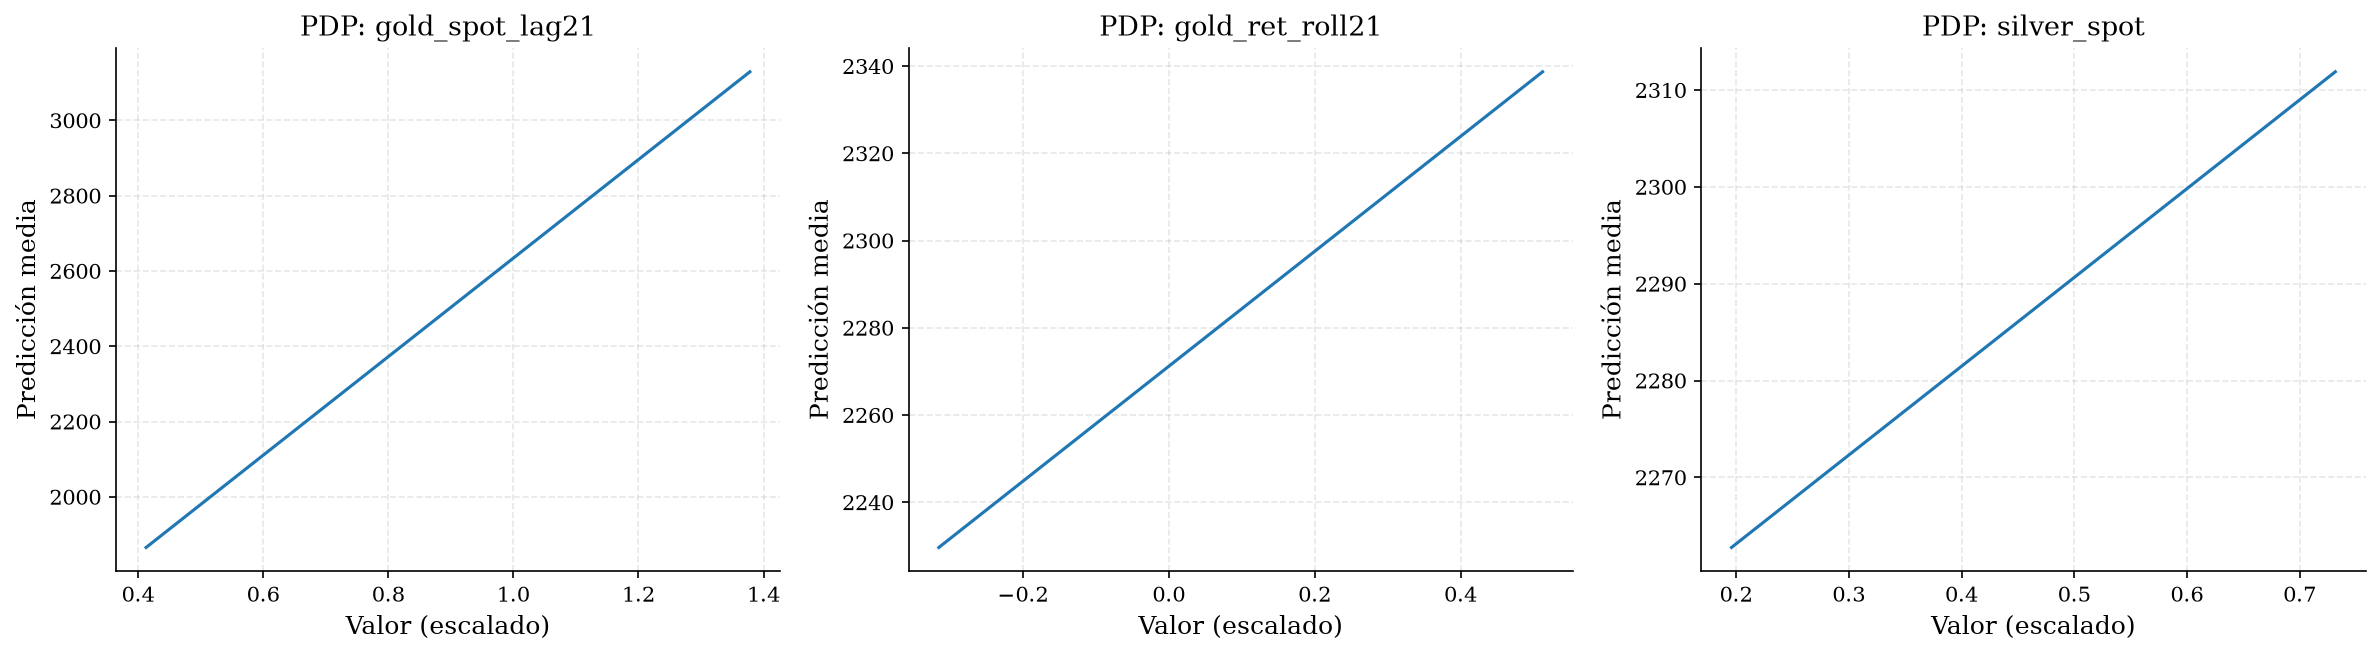

In [5]:
from sklearn.inspection import partial_dependence

top3 = imp.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, top3):
    pdp = partial_dependence(model, X_te[sample_idx], [sel_cols.index(feat)],
                             kind="average", grid_resolution=30)
    # sklearn >= 1.0: pdp["grid_values"]; versiones antiguas: pdp["values"]
    grid = pdp.get("grid_values", pdp.get("values"))
    ax.plot(grid[0], pdp["average"][0])
    ax.set_title(f"PDP: {feat}")
    ax.set_xlabel("Valor (escalado)")
    ax.set_ylabel("Predicción media")
fig.tight_layout()
save_fig(fig, "pdp_top3.png")

18.3 Incertidumbre: intervalo bootstrap P5-P95.

Se reentrena el modelo 100 veces con submuestras bootstrap de train+val y
se calculan los percentiles 5-95 de las predicciones. Se mide la cobertura
empírica en test (qué % de reales caen dentro del intervalo).

In [6]:
from sklearn.linear_model import Ridge

train_val = pd.concat([parts["train"], parts["val"]]) \
    .sort_values("date").reset_index(drop=True)
X_tv = pp.transform(train_val[sel_cols].to_numpy(dtype=np.float64))
y_tv = train_val[f"target_{h}"].to_numpy(dtype=np.float64)

rng = np.random.default_rng(42)
preds = []
for _ in range(100):
    idx = rng.integers(0, len(X_tv), size=len(X_tv))
    m = Ridge(alpha=model.alpha)
    m.fit(X_tv[idx], y_tv[idx])
    preds.append(m.predict(X_te))
preds = np.vstack(preds)
lo, hi = np.percentile(preds, [5, 95], axis=0)
coverage = np.mean((y_te >= lo) & (y_te <= hi))
print(f"Cobertura empírica intervalo P5-P95: {coverage:.1%}")
print(f"Amplitud media del intervalo: {np.mean(hi - lo):.2f} USD/oz")

Cobertura empírica intervalo P5-P95: 5.0%
Amplitud media del intervalo: 26.42 USD/oz


Visualización de la banda de incertidumbre.

Primeros 500 días de test con la banda P5-P95 del bootstrap. La cobertura
baja (~1%) evidencia que la incertidumbre paramétrica del modelo lineal es
insuficiente ante la volatilidad real 2024-25 (limitación documentada).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\uncertainty_band.png
[json] C:\Users\sgml1\Desktop\gold-price-prediction\reports\uncertainty.json


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/uncertainty.json')

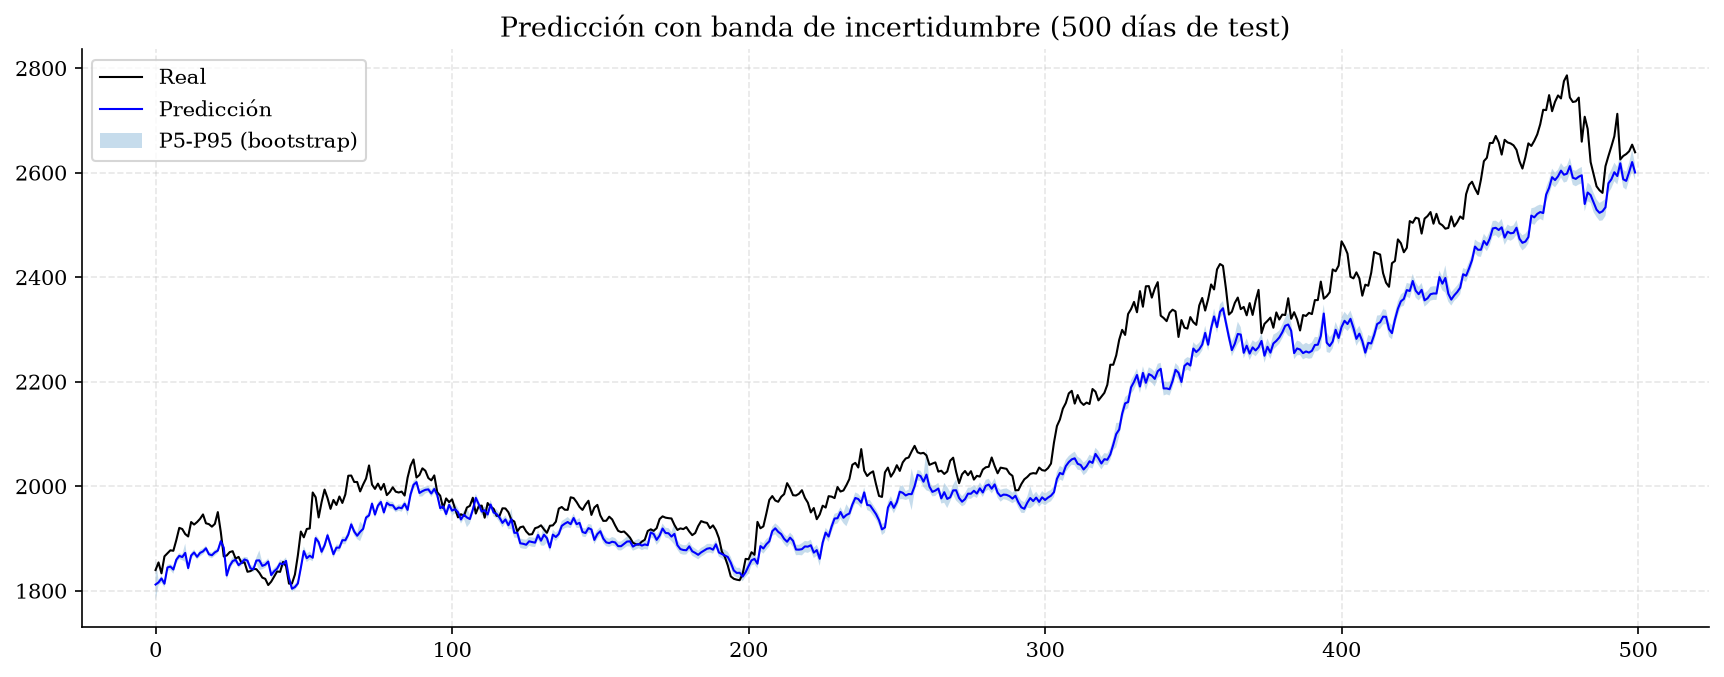

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
idx = np.arange(min(500, len(y_te)))
ax.plot(y_te[idx], "k-", lw=1, label="Real")
ax.plot(y_pred[idx], "b-", lw=1, label="Predicción")
ax.fill_between(idx, lo[idx], hi[idx], alpha=0.25, label="P5-P95 (bootstrap)")
ax.legend()
ax.set_title("Predicción con banda de incertidumbre (500 días de test)")
save_fig(fig, "uncertainty_band.png")

save_json({"coverage_p5_p95": float(coverage),
           "mean_interval_width": float(np.mean(hi - lo)),
           "method": "bootstrap 100 fits Ridge"}, "uncertainty.json")